In [1]:
import os

os.getcwd()

'/Users/evansjr/jupyter-notebooks/bondmap/source'

In [1]:
pip install -r ../requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from smiles_library import load_smiles_library

library_df  = load_smiles_library("../stored/coconut_csv-05-2026.parquet")

INFO: Loading saved library from ../stored/coconut_csv-05-2026.parquet


In [13]:
from pathlib import Path
import pandas as pd

# Specify the directory path
dir_path = Path('../nist_data')

nist_smiles = []

# Loop through items and filter for files
for file_path in dir_path.iterdir():
    if file_path.is_file():
        lib_name = file_path.name.split("_")[0]

        lib_smiles = library_df.loc[library_df["name"]==lib_name, ["smiles"]].values
        
        if len(lib_smiles) > 0:
            nist_smiles.append({
                "filename": file_path.name,
                "smiles":   lib_smiles[0][0]
            })

nist_df = pd.DataFrame(nist_smiles)

In [14]:
nist_df.to_csv('../nist_data/smiles_to_file_nist.csv')

In [1]:
from ir_processing import TrainingData

training_data = TrainingData(
                    csv_path  = "../nist_data/smiles_to_file_nist.csv",
                    spec_root = "../nist_data"
                )

In [20]:
print(training_data)

In [2]:
training_npsg_data = TrainingData(
                    csv_path  = "../training_data/smiles_to_file_V2.csv",
                    spec_root = "../training_data"
                )

In [3]:
training_data.spectra = training_data.spectra + training_npsg_data.spectra

In [91]:
from modeling import SpectIRmodeling

cls_model = SpectIRmodeling(training_data, min_pos_samples=1)

INFO: Training data provided. Initializing training pipeline...
INFO: Successfully saved model and metadata to '../stored/rf_multioutput_model.joblib'!


In [92]:
print(cls_model.summary)

Final data shape: X=(3099, 848), Y=(3099, 47)
OOB Metrics (Per-Compound / Samples): Precision=0.845, Recall=0.845, F1-Score=0.829
OOB Metrics (Per-Class / Macro):      Precision=0.675, Recall=0.494, F1-Score=0.539


In [93]:
print(cls_model.metrics)

                 FG Label  Support  Precision  Recall  F1-Score Confidence
12       alkyl_CH_stretch     2682      0.942   0.984     0.963   complete
40           CH2_CH3_bend     2653      0.940   0.982     0.961   complete
11            aromatic_CH     1714      0.847   0.976     0.907       high
38        aromatic_CH_oop     1714      0.847   0.976     0.907       high
26            aromatic_CC     1533      0.808   0.963     0.879       high
35               ether_CO     1022      0.755   0.874     0.810       high
19               ester_CO      552      0.761   0.842     0.800       high
33        ester_CO_single      552      0.761   0.842     0.800       high
1              alcohol_OH     1073      0.746   0.856     0.797       high
9               alkyne_CH       33      0.955   0.636     0.764     medium
15     terminal_alkyne_CC       33      0.955   0.636     0.764     medium
0      carboxylic_acid_OH      259      0.896   0.629     0.739       high
22     carboxylic_acid_CO

In [97]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

def tune_thresholds(model: SpectIRmodeling, threshold: float):
    n_samples, n_outputs = model.Y.shape
    y_pred_oob = np.zeros((n_samples, n_outputs))

    def max_f1(truth, probs):
        thresholds = [0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6]
        f1 = []
        for threshold in thresholds:
            pred = (probs >= threshold).astype(int)
            f1.append(f1_score(truth, pred, zero_division=0))
        # print(f1.index(max(f1)))
        return thresholds[f1.index(max(f1))]
    
    # 1. Calculate metrics per functional group
    fg_metrics = []
    for i in range(n_outputs):
        oob_probs = model.model.estimators_[i].oob_decision_function_
        threshold = max_f1(model.Y[:, i], oob_probs[:, 1])
        
        y_pred_oob[:, i] = (oob_probs[:, 1] >= threshold).astype(int)
        
        support = int(model.Y[:, i].sum())
        prec = precision_score(model.Y[:, i], y_pred_oob[:, i], zero_division=0)
        rec = recall_score(model.Y[:, i], y_pred_oob[:, i], zero_division=0)
        f1 = f1_score(model.Y[:, i], y_pred_oob[:, i], zero_division=0)

        # Baseline random chance prevalence
        prevalence = support / float(n_samples) if n_samples > 0 else 0

        # Determine the confidence tier
        if support >= 30 and prec >= 0.90 and rec >= 0.80:
            confidence = "complete"
        elif support >= 40 and f1 >= 0.70:
            confidence = "high"
        elif support >= 15 and (f1 >= 0.40 or f1 > (prevalence * 5)):
            confidence = "medium"
        else:
            confidence = "low"

        fg_metrics.append({
            "FG Label": model.labels[i],
            "Support": support,
            "Precision": round(prec, 3),
            "Recall": round(rec, 3),
            "F1-Score": round(f1, 3),
            "Confidence": confidence,
            "Threshold": threshold,
            # "type": 0,
        })

    # 2. Calculate the OVERALL Macro-Average across all valid functional groups
    overall_precision = precision_score(model.Y, y_pred_oob, average='samples', zero_division=0)
    overall_recall = recall_score(model.Y, y_pred_oob, average='samples', zero_division=0)
    overall_f1 = f1_score(model.Y, y_pred_oob, average='samples', zero_division=0)

    # 3. Append overall metrics
    total_support = int(model.Y.sum())
    fg_metrics.append({
        "FG Label": "OVERALL (Samples Avg)",
        "Support": total_support,
        "Precision": round(overall_precision, 3),
        "Recall": round(overall_recall, 3),
        "F1-Score": round(overall_f1, 3),
        "Confidence": "",
        "Threshold": round(sum([metric['Threshold'] for metric in fg_metrics])/len(fg_metrics), 3),
        # "type": 1,
    })
    
    return pd.DataFrame(fg_metrics)

df_tune = tune_thresholds(cls_model, threshold=0.45)

print(df_tune.to_string())

                 FG Label  Support  Precision  Recall  F1-Score Confidence  Threshold
0      carboxylic_acid_OH      259      0.736   0.784     0.759       high      0.250
1              alcohol_OH     1073      0.746   0.856     0.797       high      0.400
2           primary_amine      278      0.675   0.673     0.674     medium      0.350
3      secondary_amine_NH      269      0.626   0.647     0.636     medium      0.300
4      secondary_amide_NH      186      0.543   0.683     0.605     medium      0.250
5        primary_amide_NH       61      0.574   0.574     0.574     medium      0.250
6       aromatic_amine_NH       79      0.230   0.519     0.319     medium      0.150
7              pyrrole_NH      118      0.411   0.492     0.448     medium      0.250
8             aldehyde_CH      114      0.889   0.561     0.688     medium      0.300
9               alkyne_CH       33      0.923   0.727     0.814     medium      0.300
10              alkene_CH      525      0.694   0.695 

In [101]:
"""
Cross-validated threshold stability analysis for the multi-output RF model.

Goal: for each functional group, determine whether the "best F1" probability
threshold found via a single OOB pass is stable across repeated resamples,
or whether it's an artifact of small sample size / particular bootstrap draws.

Approach:
  - Repeated multi-label-stratified K-fold (falls back to repeated random
    stratified-by-row splits if `iterative-stratification` isn't installed).
  - Refit the full MultiOutputClassifier(RandomForestClassifier) pipeline on
    each training fold.
  - Predict probabilities on the held-out fold.
  - Sweep thresholds per class, record the best-F1 threshold and score.
  - Aggregate: mean/std/min/max of best-threshold and best-F1 per class
    across all fold x repeat combinations.

This tells you, per class:
  - Is the "best threshold" consistent across folds (low std)? -> trustworthy
  - Does it bounce around a lot (high std, wide min/max)? -> likely overfit to
    a handful of examples, treat current single-split threshold with caution.
"""

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
    HAS_ITERSTRAT = True
except ImportError:
    HAS_ITERSTRAT = False
    print("iterative-stratification not found — falling back to a "
          "label-cardinality-based approximate stratification. "
          "Install with: pip install iterative-stratification")


THRESHOLD_GRID = np.arange(0.05, 0.61, 0.05)


def approximate_multilabel_folds(Y: np.ndarray, n_splits: int, random_state: int):
    """
    Fallback stratification when iterstrat isn't available.
    Groups samples by their label-count "signature" bucket, then does a
    plain StratifiedKFold on that bucket. Not as rigorous as true multi-label
    stratification, but much better than a naive random split for imbalance.
    """
    label_count = Y.sum(axis=1)
    # bucket by count of labels present, capped to avoid tiny bins
    buckets = np.clip(label_count, 0, 6)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    return list(skf.split(np.zeros(len(Y)), buckets))


def get_fold_splitter(Y: np.ndarray, n_splits: int, random_state: int):
    if HAS_ITERSTRAT:
        mskf = MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        return list(mskf.split(np.zeros(len(Y)), Y))
    else:
        return approximate_multilabel_folds(Y, n_splits, random_state)


def build_model(model_params: dict, class_weight: str = "balanced", random_state: int = 42):
    base = RandomForestClassifier(
        n_estimators=model_params["n_estimators"],
        max_depth=model_params["max_depth"],
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=1,
        min_samples_leaf=model_params["min_samples_leaf"],
    )
    return MultiOutputClassifier(base, n_jobs=-1)


def best_threshold_for_class(y_true_col: np.ndarray, probs_col: np.ndarray, grid=THRESHOLD_GRID):
    """Sweep thresholds, return (best_threshold, best_f1, best_precision, best_recall)."""
    best_f1, best_t, best_p, best_r = 0.0, 0.5, 0.0, 0.0
    for t in grid:
        preds = (probs_col >= t).astype(int)
        f1 = f1_score(y_true_col, preds, zero_division=0)
        if f1 > best_f1:
            p = precision_score(y_true_col, preds, zero_division=0)
            r = recall_score(y_true_col, preds, zero_division=0)
            best_f1, best_t, best_p, best_r = f1, t, p, r
    return best_t, best_f1, best_p, best_r


def cross_validated_threshold_stability(
    X: np.ndarray,
    Y: np.ndarray,
    labels: list,
    model_params: dict,
    n_splits: int = 5,
    n_repeats: int = 5,
    class_weight: str = "balanced",
    base_random_state: int = 0,
) -> pd.DataFrame:
    """
    Main entry point. Returns a per-class DataFrame summarizing threshold
    stability across n_splits x n_repeats fold evaluations.
    """
    n_classes = Y.shape[1]
    records = {i: [] for i in range(n_classes)}  # each entry: (threshold, f1, prec, rec)

    total_runs = n_repeats * n_splits
    run_idx = 0

    for rep in range(n_repeats):
        random_state = base_random_state + rep
        folds = get_fold_splitter(Y, n_splits, random_state)

        for fold_i, (train_idx, val_idx) in enumerate(folds):
            run_idx += 1
            print(f"[{run_idx}/{total_runs}] repeat={rep} fold={fold_i} "
                  f"train={len(train_idx)} val={len(val_idx)}")

            X_train, X_val = X[train_idx], X[val_idx]
            Y_train, Y_val = Y[train_idx], Y[val_idx]

            # Skip classes with zero positives in this training fold entirely —
            # can't train a meaningful estimator for them this round.
            trainable_mask = Y_train.sum(axis=0) > 0
            if not trainable_mask.all():
                missing = [labels[i] for i in range(n_classes) if not trainable_mask[i]]
                print(f"  (skipping this fold's contribution for: {missing} — "
                      f"zero positives in this training split)")

            model = build_model(model_params, class_weight=class_weight, random_state=random_state)
            # Only fit on trainable columns to avoid sklearn errors on all-zero columns
            fit_idx = np.where(trainable_mask)[0]
            model.fit(X_train, Y_train[:, fit_idx])

            probs_val = np.zeros((len(val_idx), len(fit_idx)))
            for j, est in enumerate(model.estimators_):
                p = est.predict_proba(X_val)
                if p.shape[1] == 1:
                    probs_val[:, j] = float(est.classes_[0] == 1)
                else:
                    probs_val[:, j] = p[:, 1]

            for j, class_i in enumerate(fit_idx):
                y_true_col = Y_val[:, class_i]
                if y_true_col.sum() == 0:
                    # No positives in this val fold for this class — best-F1 search
                    # is meaningless (any threshold gives F1=0 trivially or undefined).
                    continue
                t, f1, p_, r_ = best_threshold_for_class(y_true_col, probs_val[:, j])
                records[class_i].append((t, f1, p_, r_))

    # Aggregate
    rows = []
    for i in range(n_classes):
        vals = records[i]
        support_total = int(Y[:, i].sum())
        if len(vals) == 0:
            rows.append({
                "FG Label": labels[i], "Support": support_total,
                "N Folds Evaluated": 0,
                "Threshold Mean": np.nan, "Threshold Std": np.nan,
                "Threshold Min": np.nan, "Threshold Max": np.nan,
                "F1 Mean": np.nan, "F1 Std": np.nan,
                "Stability": "insufficient data",
            })
            continue

        arr = np.array(vals)  # columns: threshold, f1, precision, recall
        t_mean, t_std = arr[:, 0].mean(), arr[:, 0].std()
        t_min, t_max = arr[:, 0].min(), arr[:, 0].max()
        f1_mean, f1_std = arr[:, 1].mean(), arr[:, 1].std()

        # Simple stability heuristic: std relative to the threshold grid spacing
        if len(vals) < 5:
            stability = "insufficient data"
        elif t_std <= 0.075:
            stability = "stable"
        elif t_std <= 0.15:
            stability = "moderate"
        else:
            stability = "unstable"

        rows.append({
            "FG Label": labels[i], "Support": support_total,
            "N Folds Evaluated": len(vals),
            "Threshold Mean": round(t_mean, 3), "Threshold Std": round(t_std, 3),
            "Threshold Min": round(t_min, 3), "Threshold Max": round(t_max, 3),
            "F1 Mean": round(f1_mean, 3), "F1 Std": round(f1_std, 3),
            "Stability": stability,
        })

    df = pd.DataFrame(rows).sort_values("Support", ascending=False).reset_index(drop=True)
    return df


# ── Example usage ──────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Load from your existing pipeline:
    from ir_processing import TrainingData
    from modeling import SpectIRmodeling
    sp = SpectIRmodeling(training_data)
    X, Y, labels = sp.X, sp.Y, sp.labels
    model_params = sp.model_params
    #
    # Then:
    results = cross_validated_threshold_stability(
        X, Y, labels, model_params,
        n_splits=5, n_repeats=10,   # more repeats = more stable estimate, slower
    )
    print(results.to_string(index=False))
    results.to_csv("threshold_stability_report.csv", index=False)
    pass

INFO: Training data provided. Initializing training pipeline...
INFO: Successfully saved model and metadata to '../stored/rf_multioutput_model.joblib'!


[1/50] repeat=0 fold=0 train=2476 val=623
[2/50] repeat=0 fold=1 train=2475 val=624
[3/50] repeat=0 fold=2 train=2487 val=612
[4/50] repeat=0 fold=3 train=2478 val=621
[5/50] repeat=0 fold=4 train=2480 val=619
[6/50] repeat=1 fold=0 train=2468 val=631
[7/50] repeat=1 fold=1 train=2483 val=616
[8/50] repeat=1 fold=2 train=2490 val=609
[9/50] repeat=1 fold=3 train=2487 val=612
[10/50] repeat=1 fold=4 train=2468 val=631
[11/50] repeat=2 fold=0 train=2475 val=624
[12/50] repeat=2 fold=1 train=2471 val=628
[13/50] repeat=2 fold=2 train=2488 val=611
[14/50] repeat=2 fold=3 train=2479 val=620
[15/50] repeat=2 fold=4 train=2483 val=616
[16/50] repeat=3 fold=0 train=2475 val=624
[17/50] repeat=3 fold=1 train=2479 val=620
[18/50] repeat=3 fold=2 train=2478 val=621
[19/50] repeat=3 fold=3 train=2479 val=620
[20/50] repeat=3 fold=4 train=2485 val=614
[21/50] repeat=4 fold=0 train=2476 val=623
[22/50] repeat=4 fold=1 train=2482 val=617
[23/50] repeat=4 fold=2 train=2482 val=617
[24/50] repeat=4 fol

In [100]:
pip install iterative-stratification


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
wn_lens = [len(spectra.wn) for spectra in training_data.spectra]

In [7]:
sum(wn_lens)/len(wn_lens)

2185.4440141981286

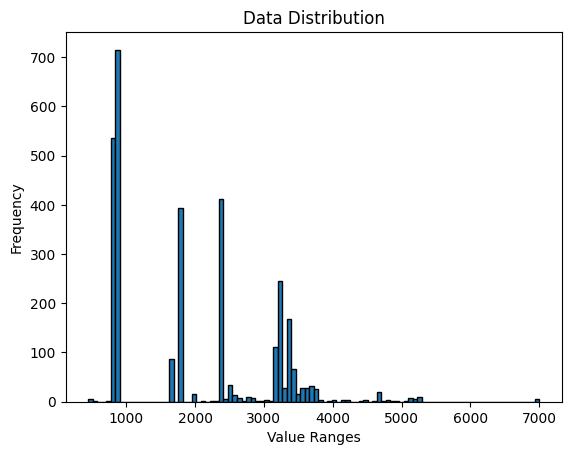

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist([wn for wn in wn_lens if wn < 10000], bins=100, edgecolor='black')

# 3. Add formatting and display
plt.title('Data Distribution')
plt.xlabel('Value Ranges')
plt.ylabel('Frequency')
plt.show()


In [25]:
from scipy.interpolate import interp1d
from sklearn.preprocessing import minmax_scale
from sklearn.preprocessing import MultiLabelBinarizer
from smiles_processing import smiles_to_fg_set
from fg_smarts_map import FG_LABELS

mlb = MultiLabelBinarizer(classes=FG_LABELS)
Y = []

# 1. Generate Mock Data (Replace this block with your actual data)
# Simulating 500 spectra with variable wavenumber lengths (745, 1650, 2377)
np.random.seed(42)

spectra_data = []
min_wn = 4000
max_wn = 400

for spec in training_data.spectra:
    wavenumbers = spec.wn
    if len(wavenumbers) >= 1000:
        min_wn = min([min_wn, min(wavenumbers)])
        max_wn = max([max_wn, max(wavenumbers)])
        absorbance = spec.absorbance
        spectra_data.append((wavenumbers, absorbance))
        # build the ground truth fg assignments
        smarts_fgs, _ = smiles_to_fg_set(spec.smiles)
        Y.append(list(smarts_fgs))

# 2. Interpolate to a Common Axis
# Define the target wavenumber range (e.g., matching the highest resolution)
common_wavenumbers = np.linspace(min_wn, max_wn, 1500)

# convert the fg assignments into binary arrays
Y_binary = mlb.fit_transform(Y)

interpolated_absorbances = []

for w, a in spectra_data:
    # Linear interpolation for missing values
    f_interp = interp1d(w, a, kind='linear', bounds_error=False, fill_value=0)
    a_interp = f_interp(common_wavenumbers)
    interpolated_absorbances.append(a_interp)

interpolated_absorbances = np.array(interpolated_absorbances)

# 3. Normalize Absorbance
# Min-Max scaling per spectrum (row-wise) to map values between 0 and 1
normalized_data = minmax_scale(interpolated_absorbances, axis=1)

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

# ── 1. PYTORCH DATASET ────────────────────────────────────────────────────────

class SpectrumDataset(Dataset):
    def __init__(self, X, Y, augment=False):
        # Add unsqueeze to create a channel dimension for the CNN
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_spec = self.X[idx]
        y_label = self.Y[idx]

        if self.augment:
            # 1. Add Gaussian Noise (Strength: 0.1% of max signal)
            noise_std = 0.001 * torch.max(x_spec)
            noise = torch.randn(x_spec.shape) * noise_std
            x_spec = x_spec + noise

            # 2. Add Baseline Shift (Shift by +/- 0.5% of max signal)
            max_shift = 0.005 * torch.max(x_spec)
            shift = (torch.rand(1) - 0.5) * 2 * max_shift
            x_spec = x_spec + shift
            
        return x_spec, y_label



# ── 2. CNN ARCHITECTURE ───────────────────────────────────────────────────────

class SpectraCNN(nn.Module):
    """
    1D Convolutional Neural Network for multi-label functional group classification.
    """
    def __init__(self, sequence_length: int, num_classes: int, k1: int=7, k2: int=5, dropout_rate: float=0.35):
        super(SpectraCNN, self).__init__()
        
        # Feature Extraction Block (Convolutions)
        self.conv_block = nn.Sequential(
            # Layer 1: Detect basic peak shapes
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=k1, stride=1, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2), # Halves the sequence length
            
            # Layer 2: Detect combined fingerprint patterns
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=k2, stride=1, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2), # Halves the sequence length again
            
            # Layer 3: Deep feature extraction
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1) # Flattens the sequence dimension perfectly to (Batch, 64, 1)
        )
        
        # Classification Block (Fully Connected)
        self.fc_block = nn.Sequential(
            nn.Flatten(), # Flattens to (Batch, 64)
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Crucial for preventing overfitting on 3000 samples
            # Output layer: 1 node per functional group. 
            # Note: No Sigmoid here! BCEWithLogitsLoss applies it automatically.
            nn.Linear(128, num_classes) 
        )

    def forward(self, x):
        features = self.conv_block(x)
        logits = self.fc_block(features)
        return logits


# ── 3. TRAINING LOOP EXAMPLE ──────────────────────────────────────────────────

def train_model(X_train: np.ndarray, Y_train: np.ndarray, num_classes: int, k1: int=7, k2: int=5, epochs: int=60):
    """
    Example function to initialize and train the CNN.
    """
    sequence_length = X_train.shape[1]
    
    # 1. Setup DataLoaders
    dataset = SpectrumDataset(X_train, Y_train)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    
    # 2. Initialize Model, Loss, and Optimizer
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SpectraCNN(sequence_length=sequence_length, num_classes=num_classes, k1=k1, k2=k2).to(device)
    
    # BCEWithLogitsLoss is mathematically more stable than Sigmoid + BCELoss
    def compute_pos_weight(Y_train, cap=None, eps=1e-6):
        """
        Compute per-class pos_weight for BCEWithLogitsLoss, guarding against
        zero-positive classes (which would otherwise produce inf/NaN).
        """
        pos_counts = Y_train.sum(axis=0)
        neg_counts = len(Y_train) - pos_counts
    
        # Add eps to denominator to avoid divide-by-zero when pos_counts == 0
        pos_weight = neg_counts / (pos_counts + eps)
    
        if cap is not None:
            # Optional: prevent extreme weights (e.g. from n=6 classes) from
            # dominating the loss and destabilizing training
            pos_weight = np.clip(pos_weight, a_min=None, a_max=cap)
    
        return torch.tensor(pos_weight, dtype=torch.float32)

    pos_weight = compute_pos_weight(Y_train, cap=60.0).to(device)
    criterion = nn.BCEWithLogitsLoss() # pos_weight=pos_weight)
    
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)

    print(pos_weight)
    
    # 3. Training Loop
    epochs = epochs
    model.train()
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        for batch_X, batch_Y in dataloader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            
            # Zero the gradients
            optimizer.zero_grad()
            
            # Forward pass
            predictions = model(batch_X)
            
            # Calculate Loss
            loss = criterion(predictions, batch_Y)
            
            # Backward pass (calculate gradients)
            loss.backward()
            
            # Update weights
            optimizer.step()
            
            epoch_loss += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(dataloader):.4f}")

        # Every 10 epochs, print the honest validation score
        if (epoch + 1) % 10 == 0:
            model.eval()
            # Run a quick validation check (using val_loader)
            val_f1, _ = evaluate_cnn(model, val_loader, threshold=0.35, device=device)
            print(f"Epoch {epoch+1} | Val F1: {val_f1:.3f}")
            model.train() # Set back to training mode
        
    return model


In [30]:
import torch
from sklearn.metrics import f1_score

def evaluate_cnn(model, dataloader, threshold=0.35, device="cpu"):
    model.eval() # Put model in evaluation mode (turns off Dropout & BatchNorm tracking)
    all_preds = []
    all_targets = []
    
    with torch.no_grad(): # Turn off gradient tracking to save memory
        for batch_X, batch_Y in dataloader:
            batch_X = batch_X.to(device)
            
            # 1. Get raw model outputs (logits)
            logits = model(batch_X)
            
            # 2. Convert logits to probabilities using Sigmoid
            probs = torch.sigmoid(logits)
            
            # 3. Apply your decision threshold (matching your RF model's 0.4)
            preds = (probs >= threshold).int().cpu().numpy()
            
            all_preds.append(preds)
            all_targets.append(batch_Y.numpy())
            
    # Combine all batches
    Y_pred = np.vstack(all_preds)
    Y_true = np.vstack(all_targets)
    
    # Calculate Samples F1 (row-wise)
    samples_f1 = f1_score(Y_true, Y_pred, average='samples', zero_division=0)
    # Calculate Macro F1 (column-wise)
    macro_f1 = f1_score(Y_true, Y_pred, average='macro', zero_division=0)
    
    print(f"--- CNN Evaluation ---")
    print(f"Samples F1-Score: {samples_f1:.3f} (RF Baseline: 0.829)")
    print(f"Macro F1-Score:   {macro_f1:.3f}")

    print(f"Total True Positives in ground truth: {Y_true.sum()}")
    print(f"Total Predicted Positives by CNN:     {Y_pred.sum()}")
    
    return samples_f1, macro_f1


In [31]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 1. Split your numpy arrays (80% train, 20% validation)
X_train_np, X_val_np, Y_train_np, Y_val_np = train_test_split(
    normalized_data, Y_binary, test_size=0.2, random_state=42, shuffle=True
)

# 1. Create the augmented dataset for training
train_dataset = SpectrumDataset(X_train_np, Y_train_np, augment=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2. Create the standard dataset for validation (NO augmentation)
val_dataset = SpectrumDataset(X_val_np, Y_val_np, augment=False)
val_loader = DataLoader(val_dataset, batch_size=256) # Larger batch for faster eval


In [45]:
# Y_binary has shape: (n_samples, n_classes)
n_classes = Y_binary.shape[1] 

# Train your CNN
trained_cnn = train_model(X_train=X_train_np, Y_train=Y_train_np, num_classes=n_classes, k1=21, k2=5, epochs=60)


tensor([ 9.6667,  1.4493,  7.5581,  8.3758, 10.9675, 31.7111, 34.9024, 16.9512,
        29.0408, 60.0000,  3.6730,  0.6614,  0.1861, 60.0000, 57.8800, 60.0000,
        60.0000, 60.0000, 60.0000,  3.9730, 38.7838,  5.4279,  9.6667, 31.7111,
        10.9675,  3.8581,  0.9043,  3.0329, 36.7436, 60.0000, 60.0000, 36.7436,
        36.7436,  3.9730,  4.2199,  1.7159,  5.4561,  5.5714,  0.6614,  3.6730,
         0.1987, 60.0000, 60.0000, 60.0000, 60.0000, 60.0000, 49.7586, 60.0000])
Epoch 1/60 | Loss: 0.3753
Epoch 2/60 | Loss: 0.2842
Epoch 3/60 | Loss: 0.2734
Epoch 4/60 | Loss: 0.2665
Epoch 5/60 | Loss: 0.2651
Epoch 6/60 | Loss: 0.2618
Epoch 7/60 | Loss: 0.2567
Epoch 8/60 | Loss: 0.2548
Epoch 9/60 | Loss: 0.2507
Epoch 10/60 | Loss: 0.2484
--- CNN Evaluation ---
Samples F1-Score: 0.600 (RF Baseline: 0.829)
Macro F1-Score:   0.169
Total True Positives in ground truth: 2628.0
Total Predicted Positives by CNN:     2377
Epoch 10 | Val F1: 0.600
Epoch 11/60 | Loss: 0.2460
Epoch 12/60 | Loss: 0.2432

In [39]:
import torch
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import pandas as pd

def evaluate_cnn(model, dataloader, threshold=0.35, device="cpu", return_probs=False):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []  # NEW: capture raw probabilities

    with torch.no_grad():
        for batch_X, batch_Y in dataloader:
            batch_X = batch_X.to(device)

            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int().cpu().numpy()

            all_preds.append(preds)
            all_targets.append(batch_Y.numpy())
            all_probs.append(probs.cpu().numpy())  # NEW

    Y_pred = np.vstack(all_preds)
    Y_true = np.vstack(all_targets)
    Y_probs = np.vstack(all_probs)  # NEW: shape (n_samples, n_classes)

    samples_f1 = f1_score(Y_true, Y_pred, average='samples', zero_division=0)
    macro_f1 = f1_score(Y_true, Y_pred, average='macro', zero_division=0)

    print(f"--- CNN Evaluation ---")
    print(f"Samples F1-Score: {samples_f1:.3f} (RF Baseline: 0.829)")
    print(f"Macro F1-Score:   {macro_f1:.3f}")
    print(f"Total True Positives in ground truth: {Y_true.sum()}")
    print(f"Total Predicted Positives by CNN:     {Y_pred.sum()}")

    if return_probs:
        return samples_f1, macro_f1, Y_probs, Y_true
    return samples_f1, macro_f1


def per_class_report(Y_true, Y_probs, threshold=0.35, class_names=None):
    """
    Per-class precision/recall/F1 at a given threshold, sklearn-style.
    """
    Y_pred = (Y_probs >= threshold).astype(int)
    n_classes = Y_true.shape[1]

    if class_names is None:
        class_names = [f"class_{i}" for i in range(n_classes)]

    rows = []
    for i in range(n_classes):
        support = int(Y_true[:, i].sum())
        p = precision_score(Y_true[:, i], Y_pred[:, i], zero_division=0)
        r = recall_score(Y_true[:, i], Y_pred[:, i], zero_division=0)
        f1 = f1_score(Y_true[:, i], Y_pred[:, i], zero_division=0)
        rows.append({"FG Label": class_names[i], "Support": support,
                     "Precision": round(p, 3), "Recall": round(r, 3), "F1-Score": round(f1, 3)})

    df = pd.DataFrame(rows).sort_values("Support", ascending=False).reset_index(drop=True)
    return df


def tune_per_class_thresholds(Y_true, Y_probs, thresholds=np.arange(0.05, 0.96, 0.05)):
    """
    Sweep thresholds per class, return best threshold + F1 per class.
    """
    n_classes = Y_true.shape[1]
    best_thresholds = np.zeros(n_classes)
    best_f1s = np.zeros(n_classes)

    for i in range(n_classes):
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (Y_probs[:, i] >= t).astype(int)
            f1 = f1_score(Y_true[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds[i] = best_t
        best_f1s[i] = best_f1

    return best_thresholds, best_f1s

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Check performance on the training data (memorization)
train_samples_f1, _ = evaluate_cnn(trained_cnn, train_loader, device=device)

# 2. Check performance on unseen validation data (true generalization)
val_samples_f1, val_macro_f1 = evaluate_cnn(trained_cnn, val_loader, device=device)


--- CNN Evaluation ---
Samples F1-Score: 0.803 (RF Baseline: 0.829)
Macro F1-Score:   0.385
Total True Positives in ground truth: 10473.0
Total Predicted Positives by CNN:     10672
--- CNN Evaluation ---
Samples F1-Score: 0.635 (RF Baseline: 0.829)
Macro F1-Score:   0.249
Total True Positives in ground truth: 2628.0
Total Predicted Positives by CNN:     2564


In [50]:
from fg_smarts_map import FG_LABELS as fg_labels

# 2. Create the standard dataset for validation (NO augmentation)
all_dataset = SpectrumDataset(normalized_data, Y_binary, augment=False)
all_loader = DataLoader(all_dataset, batch_size=256) # Larger batch for faster eval

# 1. Get probabilities on your validation set (not test set — tune thresholds on val, evaluate on test)
val_samples_f1, val_macro_f1, Y_probs_val, Y_true_val = evaluate_cnn(
    trained_cnn, all_loader, threshold=0.35, device=device, return_probs=True
)

# 2. Look at per-class performance at the current flat threshold
report_035 = per_class_report(Y_true_val, Y_probs_val, threshold=0.35, class_names=fg_labels)
print(report_035)

# 3. Find the best threshold per class
best_thresholds, best_f1s = tune_per_class_thresholds(Y_true_val, Y_probs_val)

# 4. Apply those tuned thresholds and see the new per-class report
Y_pred_tuned = (Y_probs_val >= best_thresholds).astype(int)
samples_f1_tuned = f1_score(Y_true_val, Y_pred_tuned, average='samples', zero_division=0)
macro_f1_tuned = f1_score(Y_true_val, Y_pred_tuned, average='macro', zero_division=0)
print(f"Tuned Samples F1: {samples_f1_tuned:.3f}, Tuned Macro F1: {macro_f1_tuned:.3f}")

--- CNN Evaluation ---
Samples F1-Score: 0.770 (RF Baseline: 0.829)
Macro F1-Score:   0.361
Total True Positives in ground truth: 13101.0
Total Predicted Positives by CNN:     13227
              FG Label  Support  Precision  Recall  F1-Score
0     alkyl_CH_stretch     1548      0.909   0.981     0.943
1         CH2_CH3_bend     1529      0.905   0.980     0.941
2      aromatic_CH_oop     1113      0.867   0.974     0.917
3          aromatic_CH     1113      0.867   0.973     0.917
4          aromatic_CC      978      0.821   0.964     0.887
5           alcohol_OH      748      0.675   0.846     0.751
6             ether_CO      677      0.761   0.840     0.799
7            alkene_CC      455      0.815   0.793     0.804
8        alkene_CH_wag      387      0.776   0.814     0.794
9            alkene_CH      387      0.776   0.814     0.794
10       conjugated_CO      381      0.514   0.625     0.564
11            ester_CO      356      0.725   0.742     0.733
12     ester_CO_single   

In [224]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
import numpy as np
import logging

# Make sure your SpectrumDataset is defined as before (with augmentation)

def train_and_evaluate(X_train, Y_train, X_val, Y_val, n_classes, device):
    """
    Trains a CNN with a learning rate scheduler and evaluates on validation data.
    """
    # --- Model & Hyperparameters ---
    # Use a simpler, more robust architecture
    model = SpectraCNN(sequence_length=X_train.shape[1], num_classes=n_classes, k1=11, k2=5, dropout_rate=0.35).to(device)
    
    epochs = 60
    learning_rate = 1e-3
    batch_size = 64
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=5e-4)
    
    # CRITICAL: Add the learning rate scheduler
    # It will reduce LR if validation loss doesn't improve for 5 epochs.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=5)

    # --- DataLoaders ---
    train_dataset = SpectrumDataset(X_train, Y_train, augment=True)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = SpectrumDataset(X_val, Y_val, augment=False)
    val_loader = DataLoader(val_dataset, batch_size=256)

    best_val_f1 = 0.0
    best_model_weights = None

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        train_loss = 0.0
        for batch_X, batch_Y in train_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_Y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []
        with torch.no_grad():
            for batch_X, batch_Y in val_loader:
                batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
                predictions = model(batch_X)
                loss = criterion(predictions, batch_Y)
                val_loss += loss.item()
                
                probs = torch.sigmoid(predictions).cpu().numpy()
                all_preds.append(probs)
                all_targets.append(batch_Y.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        
        # Call the scheduler with the validation loss
        scheduler.step(avg_val_loss)

        # --- Calculate F1 Score for this epoch ---
        Y_pred = (np.vstack(all_preds) >= 0.35).astype(int) # Using our tuned threshold
        Y_true = np.vstack(all_targets)
        val_f1 = f1_score(Y_true, Y_pred, average='samples', zero_division=0)

        logging.info(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Samples F1: {val_f1:.4f}")

        # --- Save the best model ---
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_weights = model.state_dict()
            logging.info(f"🚀 New best model found with F1: {best_val_f1:.4f}!")

    # --- Final Evaluation ---
    logging.info("\n--- Final Evaluation with Best Model ---")
    model.load_state_dict(best_model_weights)
    
    # Use your final `evaluate_cnn` function here to get the full report
    final_samples_f1, final_macro_f1 = evaluate_cnn(model, val_loader, threshold=0.35, device=device)
    print(f"Final Samples F1: {final_samples_f1:.3f} | Final Macro F1: {final_macro_f1:.3f}")

    return model

# Make sure your SpectraCNN __init__ accepts a dropout_rate parameter
# and call the function:
trained_model = train_and_evaluate(X_train_np, Y_train_np, X_val_np, Y_val_np, n_classes, device)


INFO: Epoch 1/60 | Train Loss: 0.3784 | Val Loss: 0.3968 | Val Samples F1: 0.5068
INFO: 🚀 New best model found with F1: 0.5068!
INFO: Epoch 2/60 | Train Loss: 0.2615 | Val Loss: 0.2428 | Val Samples F1: 0.6085
INFO: 🚀 New best model found with F1: 0.6085!
INFO: Epoch 3/60 | Train Loss: 0.2528 | Val Loss: 0.2341 | Val Samples F1: 0.6241
INFO: 🚀 New best model found with F1: 0.6241!
INFO: Epoch 4/60 | Train Loss: 0.2454 | Val Loss: 0.2307 | Val Samples F1: 0.6289
INFO: 🚀 New best model found with F1: 0.6289!
INFO: Epoch 5/60 | Train Loss: 0.2411 | Val Loss: 0.2317 | Val Samples F1: 0.6302
INFO: 🚀 New best model found with F1: 0.6302!
INFO: Epoch 6/60 | Train Loss: 0.2371 | Val Loss: 0.2259 | Val Samples F1: 0.6385
INFO: 🚀 New best model found with F1: 0.6385!
INFO: Epoch 7/60 | Train Loss: 0.2324 | Val Loss: 0.2316 | Val Samples F1: 0.6285
INFO: Epoch 8/60 | Train Loss: 0.2310 | Val Loss: 0.2213 | Val Samples F1: 0.6416
INFO: 🚀 New best model found with F1: 0.6416!
INFO: Epoch 9/60 | Tra

--- CNN Evaluation ---
Samples F1-Score: 0.693 (RF Baseline: 0.829)
Macro F1-Score:   0.238
Total True Positives in ground truth: 4010.0
Total Predicted Positives by CNN:     3749
Final Samples F1: 0.693 | Final Macro F1: 0.238


In [22]:
from sklearn.metrics import f1_score
import torch
from torch.utils.data import DataLoader

def fast_kernel_sweep(X_train, Y_train, X_val, Y_val, num_classes, device="cpu"):
    """
    Rapidly trains multiple CNN architectures for 5 epochs to evaluate 
    the best performing kernel sizes on validation data.
    """
    # Test specific pairs: (Layer 1 Kernel, Layer 2 Kernel)
    kernel_pairs = [(5, 3), (11, 5), (15, 7), (21, 5), (31, 7)]
    
    fast_lr = 0.002 
    epochs = 5 
    
    # 1. Setup DataLoader for rapid training
    train_dataset = SpectrumDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    
    # Setup Validation data as a single batch for instant F1 calculation
    val_X_tensor = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1).to(device) # Shape: (Batch, 1, Length)
    
    print(f"\n{'K1':<5} | {'K2':<5} | {'Train Loss':<15} | {'Val Samples F1':<15}")
    print("-" * 50)
    
    for k1, k2 in kernel_pairs:
        # Initialize model with test kernels (Make sure SpectraCNN accepts k1/k2!)
        model = SpectraCNN(
            sequence_length=X_train.shape[1], 
            num_classes=num_classes, 
            k1=k1, 
            k2=k2
        ).to(device)
        
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.AdamW(model.parameters(), lr=fast_lr)
        
        # 2. Fast 5-Epoch Train
        model.train()
        for epoch in range(epochs):
            epoch_loss = 0.0
            for batch_X, batch_Y in train_loader:
                batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
                optimizer.zero_grad()
                predictions = model(batch_X)
                loss = criterion(predictions, batch_Y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                
        # 3. Instant Validation Evaluation
        model.eval()
        with torch.no_grad():
            # Get raw logits and convert to probabilities
            logits = model(val_X_tensor)
            probs = torch.sigmoid(logits).cpu().numpy()
            
            # Apply your optimal threshold (0.35)
            preds = (probs >= 0.35).astype(int)
            
            # Calculate Samples F1 on unseen validation labels
            val_f1 = f1_score(Y_val, preds, average='samples', zero_division=0)
            
        print(f"{k1:<5} | {k2:<5} | {epoch_loss/len(train_loader):<15.4f} | {val_f1:<15.3f}")

fast_kernel_sweep(X_train_np, Y_train_np, X_val_np, Y_val_np, n_classes)



K1    | K2    | Train Loss      | Val Samples F1 
--------------------------------------------------
5     | 3     | 0.2424          | 0.622          
11    | 5     | 0.2411          | 0.628          
15    | 7     | 0.2394          | 0.607          
21    | 5     | 0.2368          | 0.634          
31    | 7     | 0.2313          | 0.633          


In [72]:
def find_best_threshold(model, dataloader, device="cpu"):
    model.eval()
    all_probs = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_Y in dataloader:
            batch_X = batch_X.to(device)
            probs = torch.sigmoid(model(batch_X))
            all_probs.append(probs.cpu().numpy())
            all_targets.append(batch_Y.numpy())
            
    Y_prob = np.vstack(all_probs)
    Y_true = np.vstack(all_targets)
    
    # Sweep thresholds from 0.2 to 0.6
    best_thresh = 0.4
    best_f1 = 0.0
    
    print("--- Threshold Sweep ---")
    for thresh in np.arange(0.2, 0.65, 0.05):
        Y_pred = (Y_prob >= thresh).astype(int)
        score = f1_score(Y_true, Y_pred, average='samples', zero_division=0)
        print(f"Threshold: {thresh:.2f} | Samples F1: {score:.3f}")
        
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
            
    print(f"🏆 Best Threshold: {best_thresh:.2f} with F1: {best_f1:.3f}")
    return best_thresh

find_best_threshold(trained_cnn, val_loader)

--- Threshold Sweep ---
Threshold: 0.20 | Samples F1: 0.788
Threshold: 0.25 | Samples F1: 0.801
Threshold: 0.30 | Samples F1: 0.806
Threshold: 0.35 | Samples F1: 0.809
Threshold: 0.40 | Samples F1: 0.808
Threshold: 0.45 | Samples F1: 0.804
Threshold: 0.50 | Samples F1: 0.797
Threshold: 0.55 | Samples F1: 0.790
Threshold: 0.60 | Samples F1: 0.780
🏆 Best Threshold: 0.35 with F1: 0.809


0.35

# BondMap

A Python-based cheminformatics pipeline designed to identify unknown compounds in mixtures by integrating **Infrared (IR) Spectroscopy** with **Mass Spectrometry (MS)** data. Utilizes a multi-output random forest model to predict IR functional groups using SMARTS (SMiles ARbitary Target Specification, https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html) as ground truth for IR spectral signals.

## Prerequisites
- Python 3.11 or later
- Local copy of the COCONUT library (https://coconut.naturalproducts.net/download)
  (developed/tested against the May 2026 CSV release)

## Installation

1. **Clone the repository:**
```bash
   git clone https://github.com/NCI-DCTD/bondmap.git
   cd bondmap
```

2. **Create and activate a virtual environment:**
```bash
   python -m venv bondmap
   source bondmap/bin/activate      # macOS/Linux
   bondmap\Scripts\activate         # Windows
```

3. **Install dependencies:**
```bash
   pip install -r requirements.txt
```

4. **Download the COCONUT library** and place the CSV file in a `stored/` folder at the repository root:
```
   bondmap/
   ├── source/
   │   └── bondmap.ipynb
   └── stored/
       └── coconut_csv-05-2026.csv
```
>If your file is named differently or stored elsewhere, update the path in the notebook's library-loading cell:
   ```python
      library_df = load_smiles_library("../stored/coconut_csv-05-2026.csv")
   ```

5. **(Optional) Install Jupyter, if not already installed:**
```bash
   pip install notebook
   jupyter notebook source/bondmap.ipynb
```

## Verifying your setup
Run the COCONUT-loading cell first to verify proper installation.

In [5]:
!python3 --version

Python 3.13.7
